Importing necessary libraries

In [252]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Polynomial design matrix

In [253]:

def design_matrix(X, m):
    n_samples, k = X.shape
    poly_terms = [X[:, j:j+1] ** i for j in range(k) for i in range(m + 1)]
    return np.hstack(poly_terms)

OLS implementation in matrix notation

In [254]:
def ols_regression(X, y, m):
    X_poly = design_matrix(X, m)
    # Solve the normal equation: beta = (X^T * X)^-1 * X^T * y
    beta = np.linalg.inv(X_poly.T @ X_poly) @ (X_poly.T @ y)
    return beta

Function to make predictions on new data

In [255]:
def predict(X, beta, m):
    X_poly = design_matrix(X, m)
    return X_poly @ beta

TASK C
Function to calculate SSR and Coefficient of Determination

In [256]:
def calculate_ssr_r2(y_true, y_pred):
    ssr = np.sum((y_true - y_pred) ** 2)
    ssy = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ssr / ssy
    return ssr, r2

Fucntions to plot data

In [257]:
def plot_results(X_train, y_train, X_dev, y_dev, beta, degree, fit_type):
    # Sort the X_train and y_train for plotting
    sorted_idx = np.argsort(X_train.flatten())
    X_sorted = X_train.flatten()[sorted_idx]
    y_sorted = y_train[sorted_idx]
    
    # Create an evenly spaced range of X values for smooth line plotting
    X_range = np.linspace(X_sorted.min(), X_sorted.max(), 100).reshape(-1, 1)
    y_range = predict(X_range, beta, degree)

    plt.figure(figsize=(10, 6))
    
    # Scatter plot for the gold data (train + dev combined)
    plt.scatter(np.concatenate([X_train, X_dev]), np.concatenate([y_train, y_dev]),color='blue', label='Gold Data (Train + Dev)', alpha=0.5)
    
    # Line plot for the predicted data using the fitted model
    plt.plot(X_range, y_range, color='red', label=f'Degree {degree} - {fit_type}', linewidth=2)
    
    plt.title(f'Polynomial Regression (Degree {degree})')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.savefig(f"images/3_{fit_type}.png")

Reading traning and test data from CSV files

In [258]:
train_data = pd.read_csv(r"C:\Users\aksgu\Desktop\CS215_assignments\Assignment3\q3\train.csv")
test_data = pd.read_csv(r"C:\Users\aksgu\Desktop\CS215_assignments\Assignment3\q3\test.csv")
X_train = train_data['x'].values.reshape(-1, 1)
Y_train = train_data['y'].values

X_test = test_data['x'].values.reshape(-1, 1)
ids = test_data['id'].values


Splitting data

In [259]:
def split_data(X_train,Y_train):
    x_y = np.column_stack((X_train,Y_train))
    n = x_y.shape[0]
    split_index = int(0.9*n)   #into 9:1 ratio
    train , test = np.split(x_y,[split_index])
    x_train  = train[:,0].reshape(-1,1) 
    y_train = train[:,1]
    x_dev = test[:,0].reshape(-1,1)
    y_dev = test[:,1]
    return x_train, y_train,x_dev,y_dev
    

TASK B
plotting underfit, bestfit and overfit regression based on prediction over dev set

Iterating over all possible folds for more explored training and testing dataset
fold defined as fold-1:1 ratio splitting of dataset

In [260]:
final_m = 1
final_B = None
final_MSE = np.inf
for j in [5,8,10,16,20,25,40,50,80,100]:
    Train_split = np.array(train_data[['x', 'y']].to_numpy()).reshape(j, -1, 2)
    X_fit_train_mse = []
    X_fit_test_mse = []
    Optimal_B = []
    for i in np.arange(1, 50):
        m = i+1
        optimal_Beta = None
        optimal_test_mse = []
        for Fit_test in Train_split:
            Fit_train = np.array([row for row in Train_split if not np.array_equal(row, Fit_test)]).reshape(-1,2)
            x_train = Fit_train[:,0].reshape(-1,1)
            y_train = Fit_train[:,1]
            x_dev = Fit_test[:,0].reshape(-1,1)
            y_dev = Fit_test[:,1]
            optimal_B = ols_regression(x_train, y_train, m)
            y_pred_dev = predict(x_dev, optimal_B, m)
            MSE_test,_ = calculate_ssr_r2(y_dev, y_pred_dev)
            optimal_test_mse.append(MSE_test)
        X_fit_test_mse.append(np.mean(optimal_test_mse))
        Optimal_B.append(optimal_B)
    print(f"nFolds={j}\tm={np.argmin(X_fit_test_mse)+1}\tSSR_test={np.min(X_fit_test_mse)}")

nFolds=5	m=17	SSR_test=48047.39410149202
nFolds=8	m=4	SSR_test=30172.753516439123
nFolds=10	m=4	SSR_test=24134.21439135949
nFolds=16	m=4	SSR_test=15131.851139248887
nFolds=20	m=4	SSR_test=12172.561865437183
nFolds=25	m=4	SSR_test=9730.138574657016
nFolds=40	m=4	SSR_test=6065.884919670707
nFolds=50	m=4	SSR_test=4877.160350202778
nFolds=80	m=4	SSR_test=3031.396304459431
nFolds=100	m=4	SSR_test=2435.401447229211


Using coefficient of determination for optimal degree

In [261]:

# Tracking for fit types

x_train,y_train,x_dev,y_dev=split_data(X_train,Y_train)   #splitting into 9:1
degrees_to_explore = range(1, 30)  
best_degree = None
best_beta = None
lowest_ssr = float('inf')
error_dev=[]
for degree in degrees_to_explore: 
    beta = ols_regression(x_train, y_train, degree)
    y_pred_dev = predict(x_dev, beta, degree)
    ssr_dev, r2_dev = calculate_ssr_r2(y_dev, y_pred_dev)
    error_dev.append(r2_dev)
    
best_degree = np.argmax(np.array(error_dev))+1   #degree is index+1
print("best degree", best_degree)


best degree 6


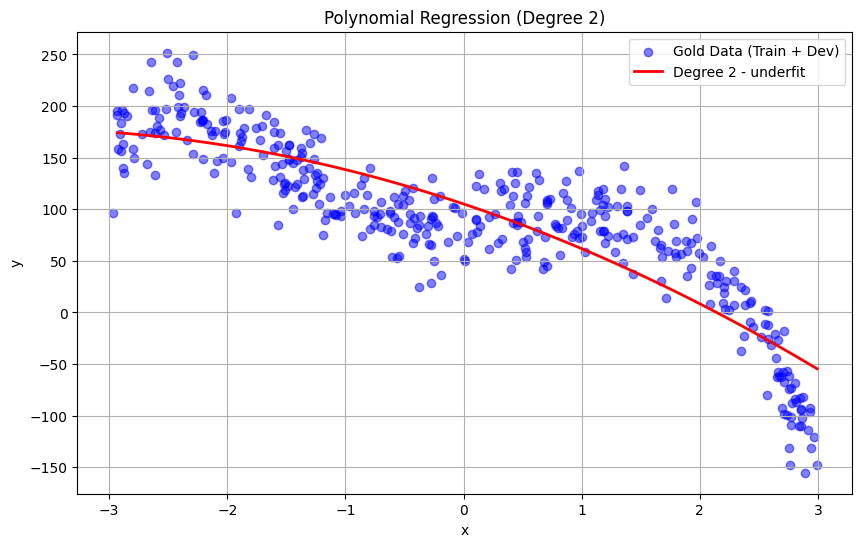

<Figure size 640x480 with 0 Axes>

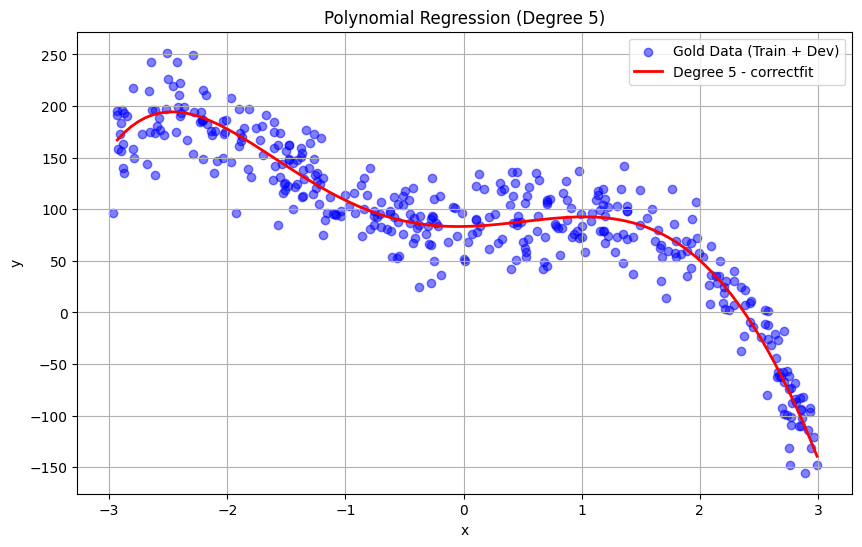

<Figure size 640x480 with 0 Axes>

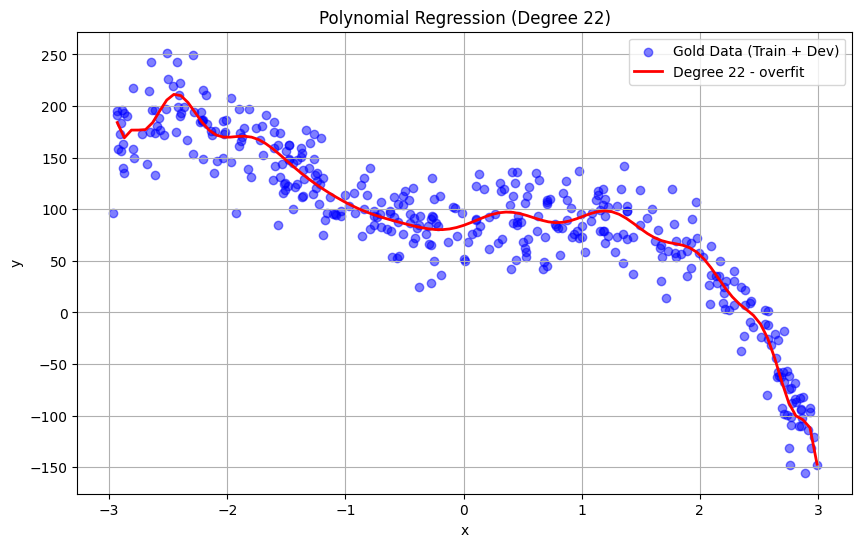

<Figure size 640x480 with 0 Axes>

In [262]:
#for degrees [1,2,3] the model is underfit, for [4,5,6] the model is best fit, while higher degrees give overfit, one each relevant plot is as follows: 
best_degree=5    #considering the above analysis based on SSR and R2, best fit is more or less same for degrees 4,5,6. However choosing degree 5
plot_results(x_train, y_train, x_dev, y_dev, ols_regression(x_train, y_train,2), 2, "underfit")
plot_results(x_train, y_train, x_dev, y_dev,ols_regression(x_train, y_train, best_degree), best_degree, "correctfit")
plot_results(x_train, y_train, x_dev, y_dev, ols_regression(x_train, y_train,22), 22, "overfit")

TASK A
Finding beta for best fit model and plotting the regression

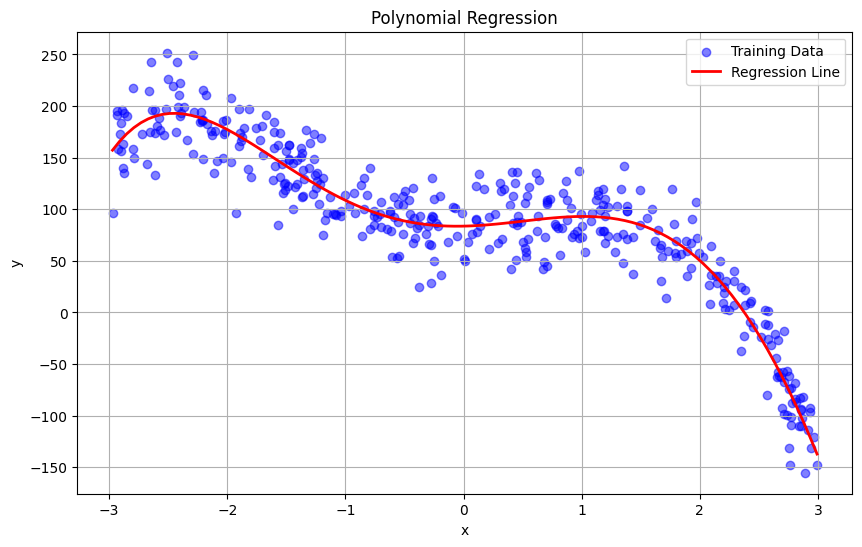

In [263]:

best_beta = ols_regression(X_train, Y_train, best_degree)
y_pred_test = predict(X_test, best_beta, best_degree)

# Convert predictions to pandas dataframe for saving to CSV
df_predictions = pd.DataFrame({'id': ids, 'x': X_test.flatten(), 'y': y_pred_test})

# Save predictions to CSV file for the best model
df_predictions.to_csv("3_predictions.csv", index=False)

# Plotting
plt.figure(figsize=(10, 6))

# Scatter plot for training data
plt.scatter(X_train, Y_train, color='blue', label='Training Data', alpha=0.5)

# Plot regression line for training data
X_range = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
y_range = predict(X_range, best_beta, best_degree)
plt.plot(X_range, y_range, color='red', label='Regression Line', linewidth=2)

plt.title('Polynomial Regression')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()